# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path to wherever the project folder lives on your Drive
    %cd /content/drive/MyDrive/revenue-predictive-model-datathon

print('IN_COLAB =', IN_COLAB)

## 1 — Imports & Config

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cwd = Path.cwd()
data_dir_candidates = [cwd / 'data', cwd.parent / 'data']
DATA_DIR = next((path.resolve() for path in data_dir_candidates if path.exists()), (cwd.parent / 'data').resolve())

TEST_FILE  = DATA_DIR / 'sample_submission.csv'
TRAIN_FILE = DATA_DIR / 'sales.csv'
OUT_FILE   = DATA_DIR / 'submission.csv'

print('DATA_DIR =', DATA_DIR)

## 2 — Load & Inspect Data

In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


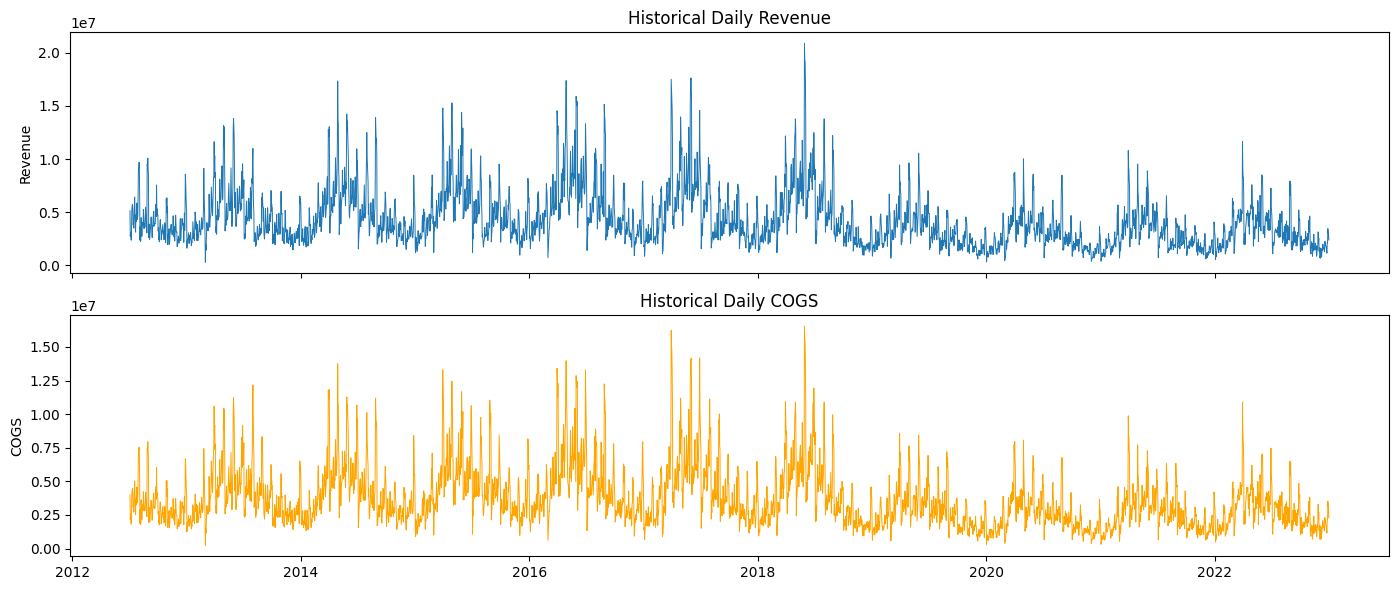

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [4]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [5]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [6]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

Seasonal profile rows: 366


,month,day,rev_norm,cogs_norm
0,1,1,0.864547,0.938006
1,1,2,0.415165,0.423207
2,1,3,0.329503,0.306372
3,1,4,0.370727,0.340570
4,1,5,0.400993,0.366576
5,1,6,0.418113,0.387441
6,1,7,0.444529,0.416864
7,1,8,0.457043,0.425623
8,1,9,0.481326,0.454805
9,1,10,0.509432,0.468719


## 5 — Predict Test Period

In [7]:
# Base level: 2022 annual mean (most recent complete year)
base_rev  = annual.loc[2022, 'Revenue']  / 365
base_cogs = annual.loc[2022, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

MAPE Revenue (2021–2022): 25.53%
MAPE COGS    (2021–2022): 23.49%


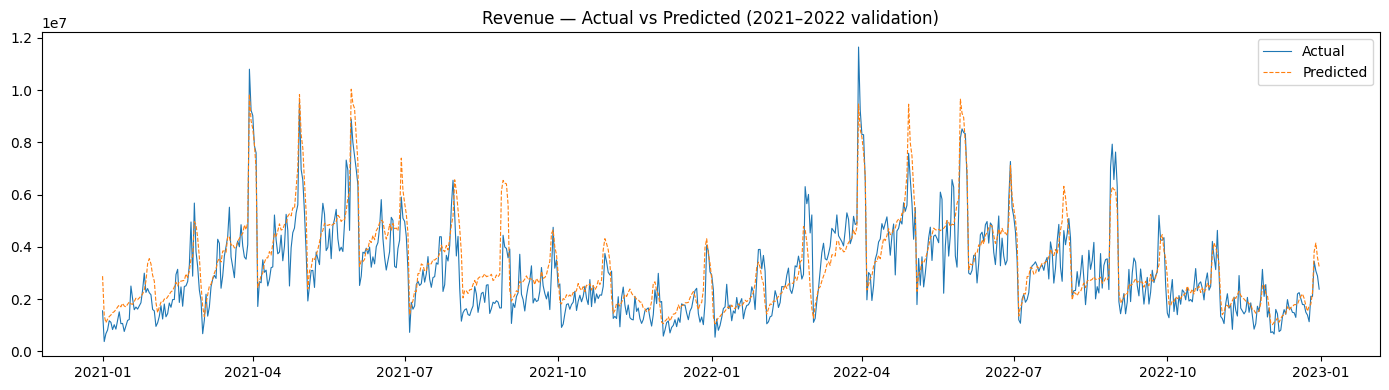

In [8]:
val = train[train['year'].isin([2021, 2022])].copy()
val = val.merge(seasonal, on=['month', 'day'], how='left')
# After merge, original 'rev_norm', 'cogs_norm' from 'train' become 'rev_norm_x', 'cogs_norm_x'
# and 'rev_norm', 'cogs_norm' from 'seasonal' become 'rev_norm_y', 'cogs_norm_y'

# Use the seasonal normalized values for prediction
val['rev_norm']  = val['rev_norm_y'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm_y'].fillna(1.0)

val['years_ahead'] = val['year'] - 2022  # negative for historical
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2021–2022): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2021–2022): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue — Actual vs Predicted (2021–2022 validation)')
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Export Submission

In [9]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 548 rows to ./data/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


## 8 — Time-Aware Cross-Validation (Folds 1–4)

Test the same seasonal-naive method on four expanding-window folds from the experiment plan.
Each fold re-computes the growth rate and seasonal profile using **only data available before the validation year** — no future data leaks in.

| Fold | Train through | Validate on | Why this fold matters |
|------|--------------|-------------|----------------------|
| Fold 1 | 2018 | 2019 | Revenue dropped ~40% — tests structural break |
| Fold 2 | 2019 | 2020 | Post-drop stabilisation year |
| Fold 3 | 2020 | 2021 | Odd year (6 promos) — same parity as the 2023 test year |
| Fold 4 | 2021 | 2022 | Most recent year — highest priority |

Metrics: **MAE** (primary), RMSE (penalises large misses), R² (variance explained), Bias (positive = model under-predicts), MAPE (scale-free %).

In [10]:
def compute_metrics(actual, predicted):
    """Return MAE, RMSE, R², Bias, and MAPE for a set of predictions."""
    errors = actual - predicted          # positive = model under-predicts
    mae    = np.abs(errors).mean()
    rmse   = np.sqrt((errors ** 2).mean())
    r2     = 1 - (errors ** 2).sum() / ((actual - actual.mean()) ** 2).sum()
    bias   = errors.mean()               # positive = under-predicts on average
    mape   = (np.abs(errors) / actual).mean() * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias, 'MAPE%': mape}


def run_baseline_on_fold(train_df, train_end_year, val_year):
    """
    Re-run the seasonal-naive + trend baseline using only data up to
    train_end_year, then predict val_year.

    This mirrors exactly what the existing baseline does — geometric mean
    YoY growth + normalised seasonal profile — but re-computed from scratch
    so no future information leaks into any fold.

    Returns: (fold_val DataFrame with Revenue_pred/COGS_pred, growth_rev, growth_cogs)
    """
    # --- Split into train and validation ---
    fold_train = train_df[train_df['year'] <= train_end_year].copy()
    fold_val   = train_df[train_df['year'] == val_year].copy()

    # Drop the norm columns added by the global seasonal profile computation
    # to avoid column name conflicts after the merge below
    fold_val = fold_val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')

    # --- Step 1: YoY growth rate (full years 2013 → train_end_year) ---
    # Exclude 2012 because it starts in July — a partial year distorts the rate
    annual     = fold_train.groupby('year')[['Revenue', 'COGS']].sum()
    full_years = annual.loc[2013:train_end_year]

    yoy_rev  = full_years['Revenue'].pct_change().dropna()
    yoy_cogs = full_years['COGS'].pct_change().dropna()

    growth_rev  = (1 + yoy_rev).prod()  ** (1 / len(yoy_rev))
    growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

    # --- Step 2: Normalised seasonal profile from fold_train only ---
    annual_means = fold_train.groupby('year')[['Revenue', 'COGS']].transform('mean')
    fold_train['rev_norm']  = fold_train['Revenue'] / annual_means['Revenue']
    fold_train['cogs_norm'] = fold_train['COGS']    / annual_means['COGS']

    seasonal_fold = (
        fold_train
        .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
        .mean()
        .reset_index()
    )

    # --- Step 3: Base level = last training year annual total / 365 ---
    base_rev  = annual.loc[train_end_year, 'Revenue'] / 365
    base_cogs = annual.loc[train_end_year, 'COGS']    / 365

    # --- Step 4: Predict ---
    fold_val = fold_val.merge(seasonal_fold, on=['month', 'day'], how='left')
    fold_val['rev_norm']  = fold_val['rev_norm'].fillna(1.0)
    fold_val['cogs_norm'] = fold_val['cogs_norm'].fillna(1.0)

    # years_ahead is always 1 for these folds (one-year-ahead forecast)
    years_ahead = val_year - train_end_year
    fold_val['Revenue_pred'] = base_rev  * growth_rev**years_ahead  * fold_val['rev_norm']
    fold_val['COGS_pred']    = base_cogs * growth_cogs**years_ahead * fold_val['cogs_norm']

    return fold_val, growth_rev, growth_cogs

In [11]:
FOLDS = [
    {'name': 'Fold 1', 'train_end': 2018, 'val_year': 2019},
    {'name': 'Fold 2', 'train_end': 2019, 'val_year': 2020},
    {'name': 'Fold 3', 'train_end': 2020, 'val_year': 2021},
    {'name': 'Fold 4', 'train_end': 2021, 'val_year': 2022},
]

fold_predictions = {}  # store val DataFrames for the plot below
summary_rows     = []  # one row per fold for the summary table

for fold in FOLDS:
    fold_val, g_rev, g_cogs = run_baseline_on_fold(
        train, fold['train_end'], fold['val_year']
    )

    rev_m  = compute_metrics(fold_val['Revenue'], fold_val['Revenue_pred'])
    cogs_m = compute_metrics(fold_val['COGS'],    fold_val['COGS_pred'])

    summary_rows.append({
        'Fold':        fold['name'],
        'Val Year':    fold['val_year'],
        'Growth Rev':  f"{(g_rev  - 1) * 100:.2f}%",
        'Growth COGS': f"{(g_cogs - 1) * 100:.2f}%",
        'Rev MAE':     f"{rev_m['MAE']:,.0f}",
        'Rev RMSE':    f"{rev_m['RMSE']:,.0f}",
        'Rev R²':      f"{rev_m['R2']:.4f}",
        'Rev Bias':    f"{rev_m['Bias']:,.0f}",
        'Rev MAPE%':   f"{rev_m['MAPE%']:.2f}%",
        'COGS MAE':    f"{cogs_m['MAE']:,.0f}",
        'COGS RMSE':   f"{cogs_m['RMSE']:,.0f}",
        'COGS R²':     f"{cogs_m['R2']:.4f}",
        'COGS Bias':   f"{cogs_m['Bias']:,.0f}",
        'COGS MAPE%':  f"{cogs_m['MAPE%']:.2f}%",
    })

    fold_predictions[fold['name']] = fold_val
    print(f"\n{fold['name']} ({fold['val_year']})  |  growth_rev={g_rev:.4f}  growth_cogs={g_cogs:.4f}")
    print(f"  Revenue : MAE={rev_m['MAE']:>12,.0f}  RMSE={rev_m['RMSE']:>12,.0f}  "
          f"R²={rev_m['R2']:.4f}  Bias={rev_m['Bias']:>12,.0f}  MAPE={rev_m['MAPE%']:.2f}%")
    print(f"  COGS    : MAE={cogs_m['MAE']:>12,.0f}  RMSE={cogs_m['RMSE']:>12,.0f}  "
          f"R²={cogs_m['R2']:.4f}  Bias={cogs_m['Bias']:>12,.0f}  MAPE={cogs_m['MAPE%']:.2f}%")

print("\n\n=== Summary Table ===")
display(pd.DataFrame(summary_rows))


Fold 1 (2019)  |  growth_rev=1.0223  growth_cogs=1.0102
  Revenue : MAE=   2,155,310  RMSE=   2,531,596  R²=-1.3815  Bias=  -2,138,115  MAPE=79.62%
  COGS    : MAE=   1,583,724  RMSE=   1,874,960  R²=-0.6979  Bias=  -1,559,399  MAPE=67.10%

Fold 2 (2020)  |  growth_rev=0.9391  growth_cogs=0.9390
  Revenue : MAE=     600,957  RMSE=     808,115  R²=0.7557  Bias=     -76,987  MAPE=26.71%
  COGS    : MAE=     488,143  RMSE=     643,978  R²=0.7775  Bias=    -186,553  MAPE=27.16%

Fold 3 (2021)  |  growth_rev=0.9375  growth_cogs=0.9306
  Revenue : MAE=     530,578  RMSE=     768,467  R²=0.7809  Bias=     119,094  MAPE=21.36%
  COGS    : MAE=     502,553  RMSE=     731,986  R²=0.7394  Bias=     299,712  MAPE=20.26%

Fold 4 (2022)  |  growth_rev=0.9438  growth_cogs=0.9461
  Revenue : MAE=     698,524  RMSE=     943,422  R²=0.6823  Bias=     480,300  MAPE=21.26%
  COGS    : MAE=     580,408  RMSE=     780,489  R²=0.7137  Bias=     337,293  MAPE=20.90%


=== Summary Table ===


,Fold,Val Year,Growth Rev,Growth COGS,Rev MAE,Rev RMSE,Rev R²,Rev Bias,Rev MAPE%,COGS MAE,COGS RMSE,COGS R²,COGS Bias,COGS MAPE%
0,Fold 1,2019,2.23%,1.02%,"2,155,310","2,531,596",-1.3815,"-2,138,115",79.62%,"1,583,724","1,874,960",-0.6979,"-1,559,399",67.10%
1,Fold 2,2020,-6.09%,-6.10%,"600,957","808,115",0.7557,"-76,987",26.71%,"488,143","643,978",0.7775,"-186,553",27.16%
2,Fold 3,2021,-6.25%,-6.94%,"530,578","768,467",0.7809,"119,094",21.36%,"502,553","731,986",0.7394,"299,712",20.26%
3,Fold 4,2022,-5.62%,-5.39%,"698,524","943,422",0.6823,"480,300",21.26%,"580,408","780,489",0.7137,"337,293",20.90%


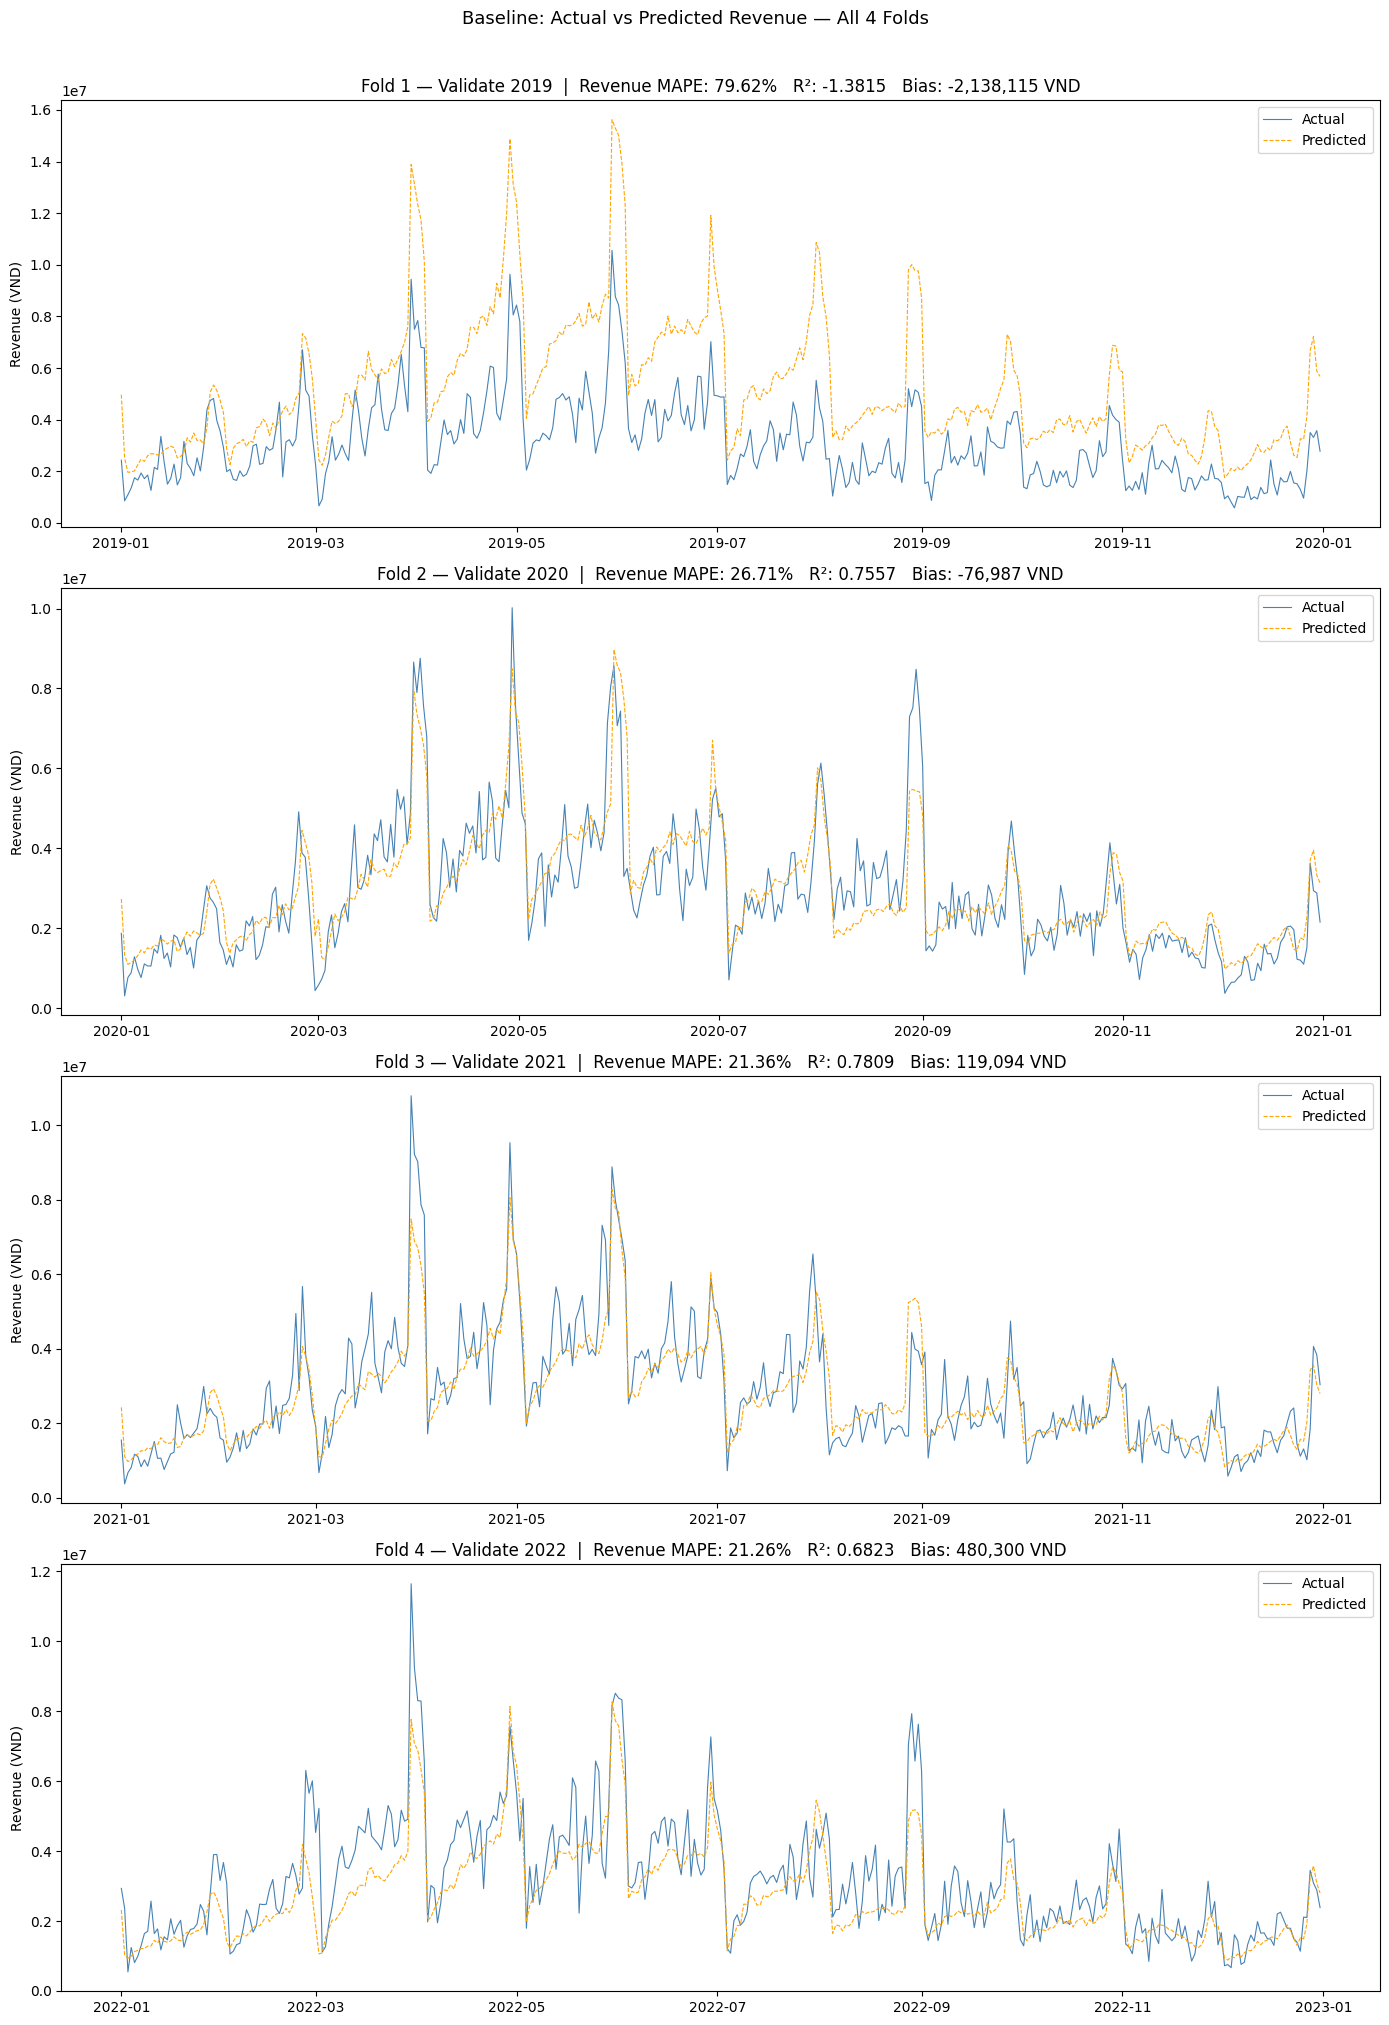

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)

for i, fold in enumerate(FOLDS):
    fold_val = fold_predictions[fold['name']]
    row      = summary_rows[i]
    ax       = axes[i]

    ax.plot(fold_val['Date'], fold_val['Revenue'],      lw=0.8, color='steelblue', label='Actual')
    ax.plot(fold_val['Date'], fold_val['Revenue_pred'], lw=0.8, color='orange',    label='Predicted', linestyle='--')

    ax.set_title(
        f"{fold['name']} — Validate {fold['val_year']}  |  "
        f"Revenue MAPE: {row['Rev MAPE%']}   R²: {row['Rev R²']}   Bias: {row['Rev Bias']} VND"
    )
    ax.set_ylabel('Revenue (VND)')
    ax.legend()

plt.suptitle('Baseline: Actual vs Predicted Revenue — All 4 Folds', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import os, shutil

# submission.csv was already saved to the project data directory by Section 7.
# When running in Colab with Drive mounted, that file is already on your Drive
# (inside the project folder). This cell also copies it to your Drive root so
# it is easy to find and download directly.

submission_src = OUT_FILE

if IN_COLAB:
    drive_root_copy = '/content/drive/MyDrive/submission_baseline.csv'
    shutil.copy(submission_src, drive_root_copy)
    print('submission.csv copied to Drive root:', drive_root_copy)
    print('Open Google Drive in your browser and download submission_baseline.csv')
else:
    print('submission.csv location:', os.path.abspath(submission_src))

# Quick validation: confirm the file has the expected 548 rows and no NaN
import pandas as pd
check = pd.read_csv(submission_src)
assert len(check) == 548,            'ERROR: expected 548 rows, got {}'.format(len(check))
assert check[['Revenue', 'COGS']].notna().all().all(), 'ERROR: NaN values found'
assert (check['Revenue'] > 0).all(), 'ERROR: non-positive Revenue found'
assert (check['COGS']    > 0).all(), 'ERROR: non-positive COGS found'
print('Checks passed: {} rows, no NaN, all values positive.'.format(len(check)))
print(check[['Date', 'Revenue', 'COGS']].head())